In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pymc as pm
import pytensor.tensor as pt

/Users/aidanbehmer/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
n_clusters_pc = 100

cc = 5.0 + 0.7*np.random.randn(n_clusters_pc)
mu_cc_true=np.mean(cc)
tau_cc_true=np.std(cc)

noise_dex_pc = 0.10

theta_true_pc_c = mu_cc_true + tau_cc_true * np.random.randn(n_clusters_pc)

In [3]:
from colossus.cosmology import cosmology 
from colossus.halo import profile_nfw
from colossus.halo import mass_so
cosmology.setCosmology("planck18") 
nfw_r = 10**np.arange(0, 2.0, 0.1)
def nfw_logSigma(theta):                         # theta = (log10 mass, concentration)
        h = profile_nfw.NFWProfile(M=10**theta[0], c=theta[1], z=0.0, mdef="vir")
        return np.log10(h.surfaceDensity(nfw_r))
class NFWProfile:
    def __init__(self, M, c, z=0.0, mdef="vir"):
        self.M = M
        self.c = c
        self.z = z
        self.mdef = mdef
        self.rhos,self.rs = self.nativeParameters_tensor(M=self.M, c=self.c)
    
    def mu(self, x):
        return pt.log(1 + x) - x/(1 + x)

    def nativeParameters_tensor(self, M, c):
        rho0 = mass_so.densityThreshold(0.0, "vir")
        R = (3 * M / (4 * np.pi * rho0)) ** (1.0/3.0)
        rs = R / c
        rhos = M / (4 * np.pi * rs**3 * self.mu(c))
        return rhos, rs
    def mu_np(self, x):
            return np.log(1 + x) - x/(1 + x)
    def nativeParameters_tensor_np(self, M, c):
            rho0 = mass_so.densityThreshold(0.0, "vir")
            R = (3 * M / (4 * np.pi * rho0)) ** (1.0/3.0)
            rs = R / c
            rhos = M / (4 * np.pi * rs**3 * self.mu_np(c))
            return rhos, rs
    
    
    def print_type(self):
        print(type(self.rhos), type(self.rs))

    
    def density(self, R):
        # Placeholder for actual NFW density calculation
        return self.rhos / ((R / self.rs) * (1 + R / self.rs)**2)
    
    #for P:
    def f_function_np(self, x):
        if x<1:
            return (1/(x**2-1))*(1-(2/np.sqrt(1-x**2))*np.arctanh(np.sqrt((1-x)/(1+x))))
        elif x==1:
            return 1/3
        else:
            return (1/(x**2-1))*(1-(2/np.sqrt(x**2-1))*np.arctan(np.sqrt((x-1)/(1+x))))
    def log_surfaceDensity_np(self, R):
        # Placeholder for actual surface density calculation
        self.rhos, self.rs = self.nativeParameters_tensor_np(M=self.M, c=self.c)
        integrand = np.zeros((len(R)), dtype=float)
        for j in range(len(R)):
            if R[j] <= 0:
                raise ValueError("R must be positive")
            integrand[j] = 2*self.rhos*self.rs*self.f_function_np(R[j]/self.rs)
        return np.log10(integrand)  # Return log10 of the integral values
    
    
    #with the tensor
    def f_function(self, x):
        f_lt = (1/(x**2-1))*(1-(2/pt.sqrt(1-x**2))*pt.arctanh(pt.sqrt((1-x)/(1+x))))
        f_eq = 1.0/3.0
        f_gt = (1/(x**2-1))*(1-(2/pt.sqrt(x**2-1))*pt.arctan(pt.sqrt((x-1)/(1+x))))

        f = pt.switch(
            pt.lt(x, 1),
            f_lt,
            pt.switch(
                pt.gt(x, 1),
                f_gt,
                f_eq
            )
        )
        return f
        #return np.log10(integrand)  # Return log10 of the integral values
    def log_surfaceDensity(self, R):
        x = pt.as_tensor_variable(R) / self.rs
        answer=2*self.rhos*self.rs*self.f_function(x)
        return pt.log10(answer)  # Return log10 of the integral values

In [5]:
c_samples=np.loadtxt('concentration_cluster_samples.csv')

with pm.Model() as hyper_model_c:

    mu = pm.Flat("mu")
    lt = pm.Uniform("lt", -10, np.log(3))

    tau = pt.exp(lt)

    total = 0

    c_samples_pt = pt.as_tensor_variable(c_samples)

    pop_density = pt.exp(
        -0.5 * ((c_samples_pt - mu) / tau) ** 2
    ) / tau
    #with a non flat prior will have to divide this by the prior density to get the correct likelihood contribution
    mc_integral = pt.mean(pop_density, axis=1)

    total = pt.sum(pt.log(mc_integral + 1e-300))

    pm.Potential("lp", total + lt)


    hyper_trace = pm.sample(
        draws=2000,
        tune=1500,
        chains=4,
        step=pm.Metropolis(),
        progressbar=False,
    )
mu_hat_c = hyper_trace.posterior["mu"].values.reshape(-1)
tau_hat_c = np.exp(
    hyper_trace.posterior["lt"].values.reshape(-1)
)

Multiprocess sampling (4 chains in 4 jobs)
CompoundStep
>Metropolis: [mu]
>Metropolis: [lt]
/Users/aidanbehmer/anaconda3/lib/python3.11/site-packages/pymc/step_methods/metropolis.py:319: RuntimeWarning: overflow encountered in exp
  "accept": np.mean(np.exp(self.accept_rate_iter)),
/Users/aidanbehmer/anaconda3/lib/python3.11/site-packages/pymc/step_methods/metropolis.py:319: RuntimeWarning: overflow encountered in exp
  "accept": np.mean(np.exp(self.accept_rate_iter)),
/Users/aidanbehmer/anaconda3/lib/python3.11/site-packages/pymc/step_methods/metropolis.py:319: RuntimeWarning: overflow encountered in exp
  "accept": np.mean(np.exp(self.accept_rate_iter)),
/Users/aidanbehmer/anaconda3/lib/python3.11/site-packages/pymc/step_methods/metropolis.py:319: RuntimeWarning: overflow encountered in exp
  "accept": np.mean(np.exp(self.accept_rate_iter)),
Sampling 4 chains for 1_500 tune and 2_000 draw iterations (6_000 + 8_000 draws total) took 33 seconds.


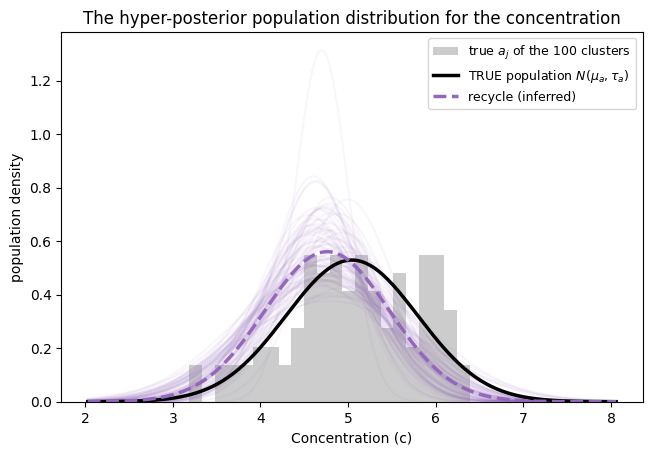

In [8]:
xx = np.linspace(mu_cc_true - 4*tau_cc_true, mu_cc_true + 4*tau_cc_true, 200)
gauss = lambda x, m, s: np.exp(-0.5*((x-m)/s)**2) / (s*np.sqrt(2*np.pi))
plt.figure(figsize=(7.5, 4.8))
plt.hist(theta_true_pc_c, bins=22, density=True, color="0.8", label="true $a_j$ of the %d clusters" % n_clusters_pc)
idx = np.random.randint(len(mu_hat_c), size=80)
for mh, th in zip(mu_hat_c[idx], tau_hat_c[idx]):                              # spaghetti from hyper-posterior
    plt.plot(xx, gauss(xx, mh, th), color="tab:purple", alpha=0.06)
plt.plot(xx, gauss(xx, mu_cc_true,    tau_cc_true),    "k-",  lw=2.5, label=r"TRUE population $N(\mu_a,\tau_a)$")
plt.plot(xx, gauss(xx, mu_hat_c.mean(), tau_hat_c.mean()), "--", color="tab:purple", lw=2.5, label="recycle (inferred)")
plt.xlabel("Concentration (c)")
plt.ylabel("population density")
plt.title("The hyper-posterior population distribution for the concentration")
plt.legend(fontsize=9)
plt.savefig("concentration_population_distribution.pdf", dpi=300)
plt.show()